# MNIST Knowledge Distillation with SVD Optimizer

Train a large teacher MLP on MNIST with Adam, then distill to a smaller student using:
1. SVD optimizer + distillation loss
2. SVD optimizer + hard labels only (baseline)
3. Adam + distillation loss (baseline)
4. Adam + hard labels only (baseline)

Also test distillation in the limited-data regime.

## 1. Setup & Data Loading

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from torch.utils.data import DataLoader, TensorDataset, Subset
from collections import defaultdict
from tqdm.auto import tqdm
import time
import copy

from sven.nn import SvenWrapper
from experiments.nn import MLP
from sven.opt import Sven

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.figsize': (8, 6),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 2,
    'axes.grid': False,
    'font.family': 'arial',
    'legend.frameon': False
})

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

#device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
device = torch.device('cuda')  if torch.cuda.is_available() else torch.device('cpu')
print(f'Device: {device}')

Device: cpu


In [15]:
import sys
sys.path.append('../')
from experiments.datasets import MNISTDataset

mnist = MNISTDataset(ROOT='../notebooks/datasets/')
train_dataset = mnist.train_dataset
val_dataset = mnist.val_dataset

print(f'Train: {len(train_dataset)} samples')
print(f'Val:   {len(val_dataset)} samples')
print(f'Input shape: {train_dataset[0][0].shape}')
print(f'Labels: {len(torch.unique(train_dataset.tensors[1]))} classes')

Train: 60000 samples
Val:   10000 samples
Input shape: torch.Size([784])
Labels: 10 classes


In [16]:
# Hyperparameters
BATCH_SIZE = 64
TEACHER_EPOCHS = 15
STUDENT_EPOCHS = 15

# Distillation params
TEMPERATURE = 4.0
ALPHA = 0.3  # weight on hard CE; (1-ALPHA) on KL distillation

# SVD optimizer params
SVD_LR = 0.1
SVD_K = 32  # k_fraction = 0.5 of batch_size=64
SVD_RTOL = 1e-3
#use_rmsprop = True

# Adam params
ADAM_LR = 1e-3

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f'Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)}')
print(f'Distillation: T={TEMPERATURE}, alpha={ALPHA}')

Batch size: 64
Train batches: 938
Distillation: T=4.0, alpha=0.3


## 2. Train Teacher Model

In [17]:
# Teacher: large MLP
teacher = MLP(input_dim=784, hidden_dims=[256, 256, 128], output_dim=10).to(device)
n_teacher_params = sum(p.numel() for p in teacher.parameters())
print(f'Teacher parameters: {n_teacher_params:,}')

# Student: small MLP
student_template = MLP(input_dim=784, hidden_dims=[32, 32], output_dim=10)
n_student_params = sum(p.numel() for p in student_template.parameters())
print(f'Student parameters: {n_student_params:,}')
print(f'Compression ratio: {n_teacher_params / n_student_params:.1f}x')

Teacher parameters: 300,938
Student parameters: 26,506
Compression ratio: 11.4x


In [18]:
# Train teacher with Adam
teacher_optimizer = torch.optim.Adam(teacher.parameters(), lr=ADAM_LR)
ce_loss = nn.CrossEntropyLoss()

teacher_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in tqdm(range(TEACHER_EPOCHS), desc='Teacher training'):
    teacher.train()
    epoch_loss, epoch_correct, epoch_total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        teacher_optimizer.zero_grad()
        logits = teacher(xb)
        loss = ce_loss(logits, yb)
        loss.backward()
        teacher_optimizer.step()
        epoch_loss += loss.item() * len(xb)
        epoch_correct += (logits.argmax(1) == yb).sum().item()
        epoch_total += len(xb)
    teacher_history['train_loss'].append(epoch_loss / epoch_total)
    teacher_history['train_acc'].append(epoch_correct / epoch_total)

    teacher.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = teacher(xb)
            loss = ce_loss(logits, yb)
            val_loss += loss.item() * len(xb)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total += len(xb)
    teacher_history['val_loss'].append(val_loss / val_total)
    teacher_history['val_acc'].append(val_correct / val_total)

print(f'\nTeacher final: train_acc={teacher_history["train_acc"][-1]*100:.1f}%, '
      f'val_acc={teacher_history["val_acc"][-1]*100:.1f}%')

Teacher training: 100%|██████████| 15/15 [00:34<00:00,  2.29s/it]


Teacher final: train_acc=99.5%, val_acc=97.9%


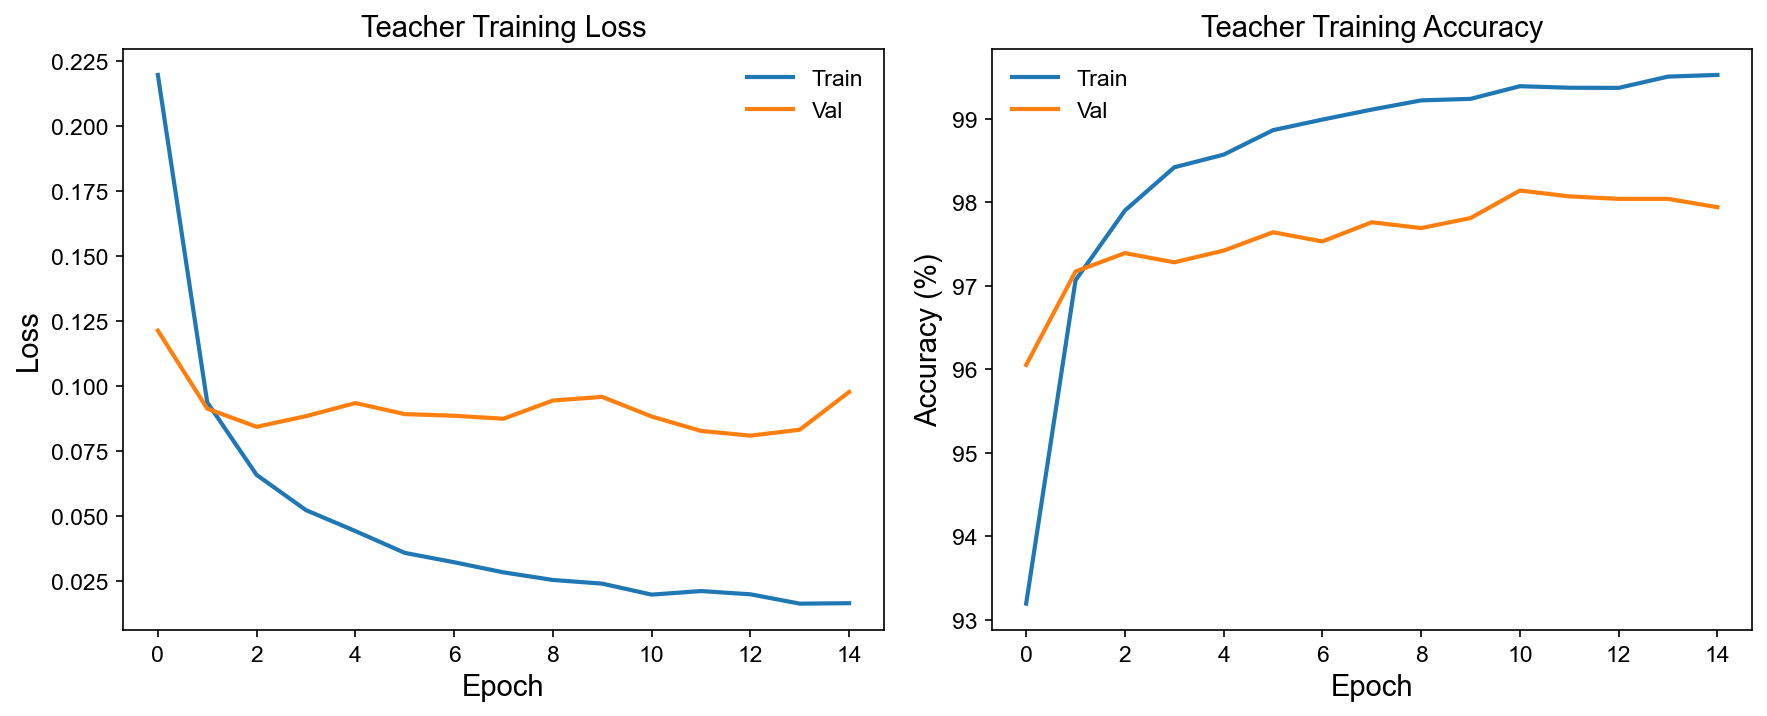

In [19]:
# Plot teacher training
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(teacher_history['train_loss'], label='Train')
ax.plot(teacher_history['val_loss'], label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Teacher Training Loss')
ax.legend()

ax = axes[1]
ax.plot([a*100 for a in teacher_history['train_acc']], label='Train')
ax.plot([a*100 for a in teacher_history['val_acc']], label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Teacher Training Accuracy')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Pre-compute Teacher Logits

In [20]:
# Pre-compute teacher logits for the full training and validation sets
teacher.eval()

def compute_teacher_logits(dataset, batch_size=512):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_logits = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = teacher(xb)
            all_logits.append(logits.cpu())
    return torch.cat(all_logits, dim=0)

train_teacher_logits = compute_teacher_logits(train_dataset)
val_teacher_logits = compute_teacher_logits(val_dataset)

# Create distillation datasets: (x, y, teacher_logits)
train_x, train_y = train_dataset.tensors
val_x, val_y = val_dataset.tensors

distill_train_dataset = TensorDataset(train_x, train_y, train_teacher_logits)
distill_val_dataset = TensorDataset(val_x, val_y, val_teacher_logits)

distill_train_loader = DataLoader(distill_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                  generator=torch.Generator().manual_seed(SEED))
distill_val_loader = DataLoader(distill_val_dataset, batch_size=256, shuffle=False)

print(f'Teacher logits shape: {train_teacher_logits.shape}')
print(f'Distillation train dataset: {len(distill_train_dataset)} samples')

Teacher logits shape: torch.Size([60000, 10])
Distillation train dataset: 60000 samples


## 4. Define Distillation Loss Functions

In [21]:
# Per-sample distillation loss (for SVD optimizer — returns shape (B,))
def distill_loss_fn(student_logits, labels, teacher_logits):
    """Distillation loss: alpha * CE(student, label) + (1-alpha) * T^2 * KL(teacher || student)"""
    # Hard label loss (per-sample)
    hard_loss = F.cross_entropy(student_logits, labels, reduction='none')

    # Soft label loss (per-sample KL divergence)
    student_log_probs = F.log_softmax(student_logits / TEMPERATURE, dim=-1)
    teacher_probs = F.softmax(teacher_logits / TEMPERATURE, dim=-1)
    # KL(teacher || student) = sum over classes of teacher_prob * (log(teacher_prob) - log(student_prob))
    kl_loss = F.kl_div(student_log_probs, teacher_probs, reduction='none').sum(dim=-1)

    loss = ALPHA * hard_loss + (1 - ALPHA) * (TEMPERATURE ** 2) * kl_loss
    return loss

# Scalar distillation loss (for Adam optimizer)
def distill_loss_fn_scalar(student_logits, labels, teacher_logits):
    return distill_loss_fn(student_logits, labels, teacher_logits).mean()

# Per-sample CE loss (for SVD, no distillation)
def ce_loss_fn(pred, y):
    return F.cross_entropy(pred, y, reduction='none')

# Scalar CE loss (for Adam, no distillation)
ce_loss_scalar = nn.CrossEntropyLoss()

# Quick test
test_student = torch.randn(4, 10)
test_teacher = torch.randn(4, 10)
test_labels = torch.tensor([0, 1, 2, 3])
print(f'Distill loss shape: {distill_loss_fn(test_student, test_labels, test_teacher).shape}')
print(f'CE loss shape: {ce_loss_fn(test_student, test_labels).shape}')

Distill loss shape: torch.Size([4])
CE loss shape: torch.Size([4])


## 5. Training Utilities

In [22]:
def compute_accuracy(model, loader, device, is_functional=False):
    """Compute accuracy on a dataset. Handles both raw models and SvenWrapper."""
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            xb = batch[0].to(device)
            yb = batch[1].to(device)
            if is_functional:
                logits = model.evaluate(xb)
            else:
                logits = model(xb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(yb)
    return correct / total


def train_student_svd(model, loss_fn, train_loader, val_loader, num_epochs, device,
                      lr, k, rtol, use_distill=True):
    """Train a student with the SVD optimizer. Handles both 2-tuple and 3-tuple batches."""
    func_model = SvenWrapper(model, loss_fn, device=device)
    optimizer = Sven(func_model, lr=lr, k=k, rtol=rtol,
                            track_svd_info=True, svd_mode='randomized',
                            use_rmsprop=True)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'epoch_times': []}

    # Validation loaders: use the 2-tuple version for accuracy, but the right loader for loss
    # For distillation, val_loader has 3-tuples; for hard labels, 2-tuples

    with torch.no_grad():
        for epoch in tqdm(range(num_epochs), desc='SVD student'):
            t0 = time.perf_counter()
            epoch_train_losses = []

            for batch_data in train_loader:
                batch_data = tuple(t.to(device) for t in batch_data)
                batch = batch_data  # (x, y) or (x, y, teacher_logits)
                batch_losses, ypred = func_model.loss_and_grad(batch)
                optimizer.step(batch)
                epoch_train_losses.append(batch_losses.mean().item())

            # Validation loss
            epoch_val_losses = []
            for batch_data in val_loader:
                batch_data = tuple(t.to(device) for t in batch_data)
                xb = batch_data[0]
                args = batch_data[1:]
                ypred = func_model.evaluate(xb)
                vloss = loss_fn(ypred, *args).mean().item()
                epoch_val_losses.append(vloss)

            history['train_loss'].append(np.mean(epoch_train_losses))
            history['val_loss'].append(np.mean(epoch_val_losses))
            history['epoch_times'].append(time.perf_counter() - t0)

    # Compute final accuracy on standard val set (2-tuple)
    val_acc = compute_accuracy(func_model, val_loader, device, is_functional=True)
    history['final_val_acc'] = val_acc
    history['total_time'] = sum(history['epoch_times'])

    return func_model, optimizer, history


def train_student_adam(model, loss_fn, train_loader, val_loader, num_epochs, device, lr):
    """Train a student with Adam. Handles both 2-tuple and 3-tuple batches."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'epoch_times': []}

    for epoch in tqdm(range(num_epochs), desc='Adam student'):
        t0 = time.perf_counter()
        model.train()
        epoch_train_losses = []

        for batch_data in train_loader:
            batch_data = tuple(t.to(device) for t in batch_data)
            xb = batch_data[0]
            args = batch_data[1:]
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, *args)
            if loss.dim() > 0:
                loss = loss.mean()
            loss.backward()
            optimizer.step()
            epoch_train_losses.append(loss.item())

        model.eval()
        epoch_val_losses = []
        with torch.no_grad():
            for batch_data in val_loader:
                batch_data = tuple(t.to(device) for t in batch_data)
                xb = batch_data[0]
                args = batch_data[1:]
                logits = model(xb)
                vloss = loss_fn(logits, *args)
                if vloss.dim() > 0:
                    vloss = vloss.mean()
                epoch_val_losses.append(vloss.item())

        history['train_loss'].append(np.mean(epoch_train_losses))
        history['val_loss'].append(np.mean(epoch_val_losses))
        history['epoch_times'].append(time.perf_counter() - t0)

    val_acc = compute_accuracy(model, val_loader, device, is_functional=False)
    history['final_val_acc'] = val_acc
    history['total_time'] = sum(history['epoch_times'])

    return model, optimizer, history


def make_fresh_student():
    """Create a fresh student model with the same initial weights."""
    torch.manual_seed(SEED + 1)  # consistent init across experiments
    return MLP(input_dim=784, hidden_dims=[32, 32], output_dim=10)

## 6. Train All Student Variants (Full Data)

In [23]:
# 6a. SVD + Distillation
print('Training: SVD + Distillation')
model_svd_distill, opt_svd_distill, hist_svd_distill = train_student_svd(
    make_fresh_student(), distill_loss_fn,
    distill_train_loader, distill_val_loader,
    STUDENT_EPOCHS, 'cpu' if device=='mps' else device, lr=SVD_LR, k=SVD_K, rtol=SVD_RTOL
)
print(f'  Val acc: {hist_svd_distill["final_val_acc"]*100:.2f}%')

Training: SVD + Distillation


SVD student:   0%|          | 0/15 [00:00<?, ?it/s]/Users/sambt/miniforge3/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
/Users/sambt/miniforge3/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
SVD student: 100%|██████████| 15/15 [07:44<00:00, 30.96s/it]

  Val acc: 91.32%


In [24]:
# 6b. SVD + Hard labels only
print('Training: SVD + Hard Labels')
model_svd_hard, opt_svd_hard, hist_svd_hard = train_student_svd(
    make_fresh_student(), ce_loss_fn,
    train_loader, val_loader,
    STUDENT_EPOCHS, 'cpu' if device=='mps' else device, lr=SVD_LR, k=SVD_K, rtol=SVD_RTOL
)
print(f'  Val acc: {hist_svd_hard["final_val_acc"]*100:.2f}%')

Training: SVD + Hard Labels


SVD student:   0%|          | 0/15 [00:00<?, ?it/s]/Users/sambt/miniforge3/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
/Users/sambt/miniforge3/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
SVD student: 100%|██████████| 15/15 [07:36<00:00, 30.42s/it]

  Val acc: 88.00%


In [25]:
# 6c. Adam + Distillation
print('Training: Adam + Distillation')
model_adam_distill, opt_adam_distill, hist_adam_distill = train_student_adam(
    make_fresh_student(), distill_loss_fn,
    distill_train_loader, distill_val_loader,
    STUDENT_EPOCHS, device, lr=ADAM_LR
)
print(f'  Val acc: {hist_adam_distill["final_val_acc"]*100:.2f}%')

Training: Adam + Distillation


Adam student: 100%|██████████| 15/15 [00:16<00:00,  1.11s/it]

  Val acc: 96.92%


In [26]:
# 6d. Adam + Hard labels only
print('Training: Adam + Hard Labels')
model_adam_hard, opt_adam_hard, hist_adam_hard = train_student_adam(
    make_fresh_student(), ce_loss_fn,
    train_loader, val_loader,
    STUDENT_EPOCHS, device, lr=ADAM_LR
)
print(f'  Val acc: {hist_adam_hard["final_val_acc"]*100:.2f}%')

Training: Adam + Hard Labels


Adam student: 100%|██████████| 15/15 [00:14<00:00,  1.04it/s]

  Val acc: 97.05%


## 7. Compare All Approaches (Full Data)

In [27]:
# Collect results
all_results = {
    'SVD + Distill':  hist_svd_distill,
    'SVD + Hard':     hist_svd_hard,
    'Adam + Distill': hist_adam_distill,
    'Adam + Hard':    hist_adam_hard,
}

print(f'{"Method":<20s} {"Val Acc (%)":>12s} {"Time (s)":>10s}')
print('-' * 44)
teacher_val_acc = teacher_history['val_acc'][-1]
print(f'{"Teacher (Adam)":<20s} {teacher_val_acc*100:>11.2f}% {"--":>10s}')
for name, hist in all_results.items():
    print(f'{name:<20s} {hist["final_val_acc"]*100:>11.2f}% {hist["total_time"]:>9.1f}s')

Method                Val Acc (%)   Time (s)
--------------------------------------------
Teacher (Adam)             97.94%         --
SVD + Distill              91.32%     464.4s
SVD + Hard                 88.00%     456.2s
Adam + Distill             96.92%      16.7s
Adam + Hard                97.05%      14.5s


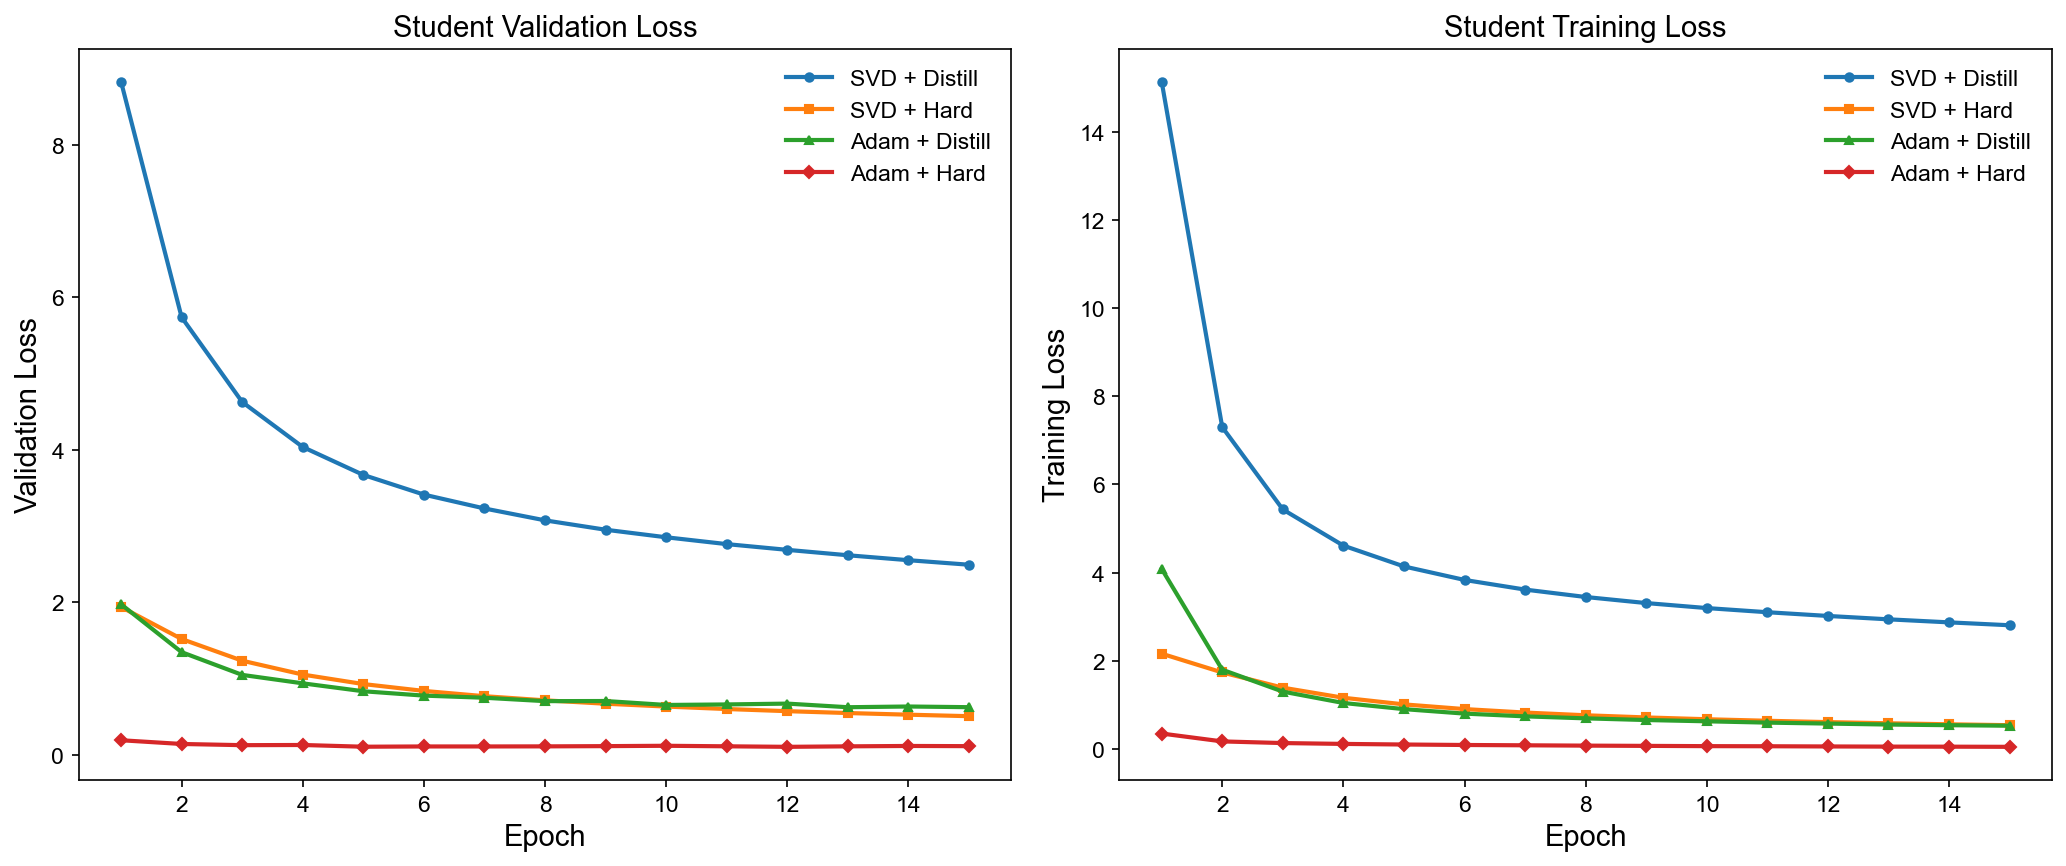

In [28]:
# Training curves
colors = {'SVD + Distill': 'C0', 'SVD + Hard': 'C1', 'Adam + Distill': 'C2', 'Adam + Hard': 'C3'}
markers = {'SVD + Distill': 'o', 'SVD + Hard': 's', 'Adam + Distill': '^', 'Adam + Hard': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Val loss
ax = axes[0]
for name, hist in all_results.items():
    epochs = range(1, len(hist['val_loss']) + 1)
    ax.plot(epochs, hist['val_loss'], color=colors[name], marker=markers[name],
            markersize=4, markevery=max(1, len(hist['val_loss'])//10), label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Student Validation Loss')
ax.legend()

# Train loss
ax = axes[1]
for name, hist in all_results.items():
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], color=colors[name], marker=markers[name],
            markersize=4, markevery=max(1, len(hist['train_loss'])//10), label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Student Training Loss')
ax.legend()

plt.tight_layout()
plt.show()

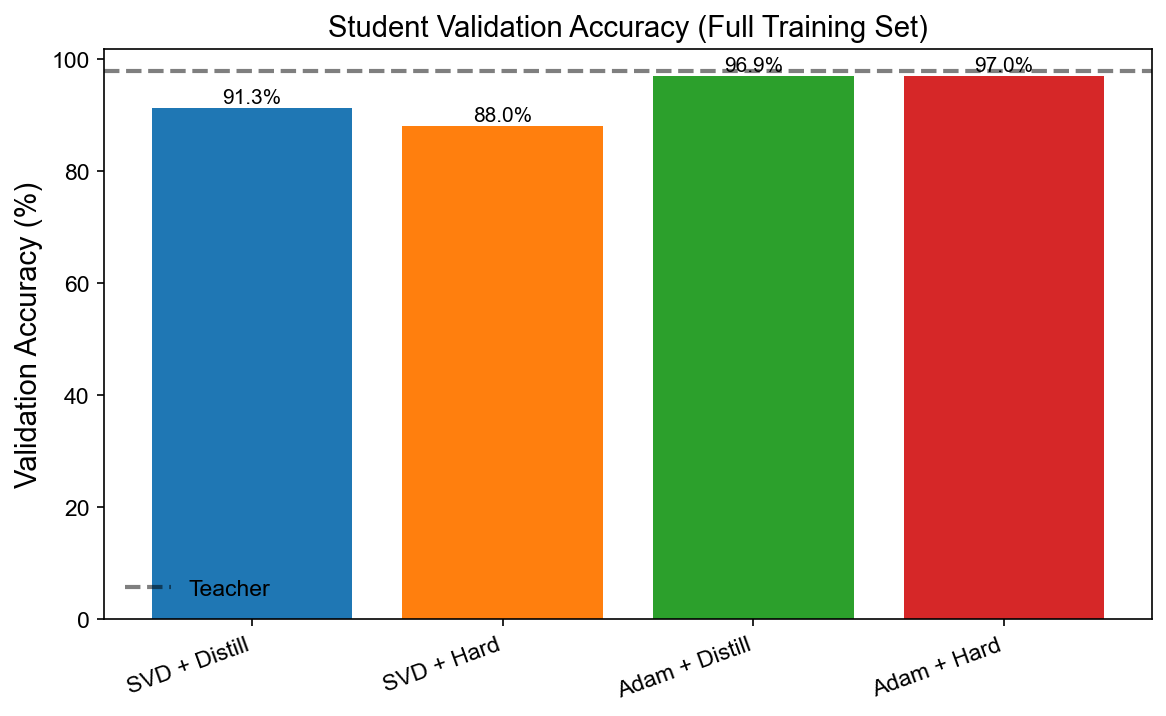

In [29]:
# Bar chart: final val accuracy
fig, ax = plt.subplots(figsize=(8, 5))

names = list(all_results.keys())
accs = [all_results[n]['final_val_acc'] * 100 for n in names]
bar_colors = [colors[n] for n in names]

x = np.arange(len(names))
bars = ax.bar(x, accs, color=bar_colors)
ax.axhline(y=teacher_val_acc * 100, color='k', linestyle='--', alpha=0.5, label='Teacher')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Student Validation Accuracy (Full Training Set)')
ax.legend()

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Limited Data Regime

Test how distillation with the SVD optimizer performs when training data is scarce.

In [ ]:
subset_sizes = [500, 1000, 5000, 10000, 60000]
limited_results = {size: {} for size in subset_sizes}

for n_train in subset_sizes:
    print(f'\n{"="*60}')
    print(f'Training with {n_train} samples')
    print(f'{"="*60}')

    # Create subset
    if n_train < len(train_dataset):
        rng = torch.Generator().manual_seed(SEED)
        indices = torch.randperm(len(train_dataset), generator=rng)[:n_train]
        sub_train = Subset(train_dataset, indices)
        sub_distill_train = Subset(distill_train_dataset, indices)
    else:
        sub_train = train_dataset
        sub_distill_train = distill_train_dataset

    sub_train_loader = DataLoader(sub_train, batch_size=BATCH_SIZE, shuffle=True,
                                  generator=torch.Generator().manual_seed(SEED))
    sub_distill_loader = DataLoader(sub_distill_train, batch_size=BATCH_SIZE, shuffle=True,
                                    generator=torch.Generator().manual_seed(SEED))

    # SVD + Distillation
    print('  SVD + Distillation...')
    _, _, h = train_student_svd(
        make_fresh_student(), distill_loss_fn,
        sub_distill_loader, distill_val_loader,
        STUDENT_EPOCHS, device, lr=SVD_LR, k=min(SVD_K, BATCH_SIZE), rtol=SVD_RTOL
    )
    limited_results[n_train]['SVD + Distill'] = h
    print(f'    Val acc: {h["final_val_acc"]*100:.2f}%')

    # SVD + Hard labels
    print('  SVD + Hard Labels...')
    _, _, h = train_student_svd(
        make_fresh_student(), ce_loss_fn,
        sub_train_loader, val_loader,
        STUDENT_EPOCHS, device, lr=SVD_LR, k=min(SVD_K, BATCH_SIZE), rtol=SVD_RTOL
    )
    limited_results[n_train]['SVD + Hard'] = h
    print(f'    Val acc: {h["final_val_acc"]*100:.2f}%')

    # Adam + Distillation
    print('  Adam + Distillation...')
    _, _, h = train_student_adam(
        make_fresh_student(), distill_loss_fn,
        sub_distill_loader, distill_val_loader,
        STUDENT_EPOCHS, device, lr=ADAM_LR
    )
    limited_results[n_train]['Adam + Distill'] = h
    print(f'    Val acc: {h["final_val_acc"]*100:.2f}%')

    # Adam + Hard labels
    print('  Adam + Hard Labels...')
    _, _, h = train_student_adam(
        make_fresh_student(), ce_loss_fn,
        sub_train_loader, val_loader,
        STUDENT_EPOCHS, device, lr=ADAM_LR
    )
    limited_results[n_train]['Adam + Hard'] = h
    print(f'    Val acc: {h["final_val_acc"]*100:.2f}%')

In [ ]:
# Print summary table
methods = ['SVD + Distill', 'SVD + Hard', 'Adam + Distill', 'Adam + Hard']

print(f'{"N_train":<10s}', end='')
for m in methods:
    print(f'{m:>18s}', end='')
print()
print('-' * (10 + 18 * len(methods)))
for n_train in subset_sizes:
    print(f'{n_train:<10d}', end='')
    for m in methods:
        acc = limited_results[n_train][m]['final_val_acc'] * 100
        print(f'{acc:>17.2f}%', end='')
    print()

In [ ]:
# Plot: accuracy vs dataset size
fig, ax = plt.subplots(figsize=(10, 6))

for method in methods:
    accs = [limited_results[n][method]['final_val_acc'] * 100 for n in subset_sizes]
    ax.plot(subset_sizes, accs, 'o-', color=colors[method], label=method,
            markersize=6, lw=2)

ax.axhline(y=teacher_val_acc * 100, color='k', linestyle='--', alpha=0.5, label='Teacher')

ax.set_xscale('log')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Student Accuracy vs Training Data Size')
ax.set_xticks(subset_sizes)
ax.set_xticklabels([str(s) for s in subset_sizes])
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Plot: distillation advantage (distill - hard labels) for each optimizer
fig, ax = plt.subplots(figsize=(10, 6))

svd_advantage = []
adam_advantage = []
for n in subset_sizes:
    svd_d = limited_results[n]['SVD + Distill']['final_val_acc']
    svd_h = limited_results[n]['SVD + Hard']['final_val_acc']
    adam_d = limited_results[n]['Adam + Distill']['final_val_acc']
    adam_h = limited_results[n]['Adam + Hard']['final_val_acc']
    svd_advantage.append((svd_d - svd_h) * 100)
    adam_advantage.append((adam_d - adam_h) * 100)

ax.plot(subset_sizes, svd_advantage, 'o-', color='C0', label='SVD: distill - hard', lw=2, markersize=6)
ax.plot(subset_sizes, adam_advantage, 's-', color='C2', label='Adam: distill - hard', lw=2, markersize=6)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)

ax.set_xscale('log')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy Gain from Distillation (pp)')
ax.set_title('Distillation Advantage vs Training Data Size')
ax.set_xticks(subset_sizes)
ax.set_xticklabels([str(s) for s in subset_sizes])
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Plot: training curves at each data size
fig, axes = plt.subplots(1, len(subset_sizes), figsize=(4 * len(subset_sizes), 4), sharey=True)

for ax, n_train in zip(axes, subset_sizes):
    for method in methods:
        hist = limited_results[n_train][method]
        epochs = range(1, len(hist['val_loss']) + 1)
        ax.plot(epochs, hist['val_loss'], color=colors[method], lw=1.5, label=method)
    ax.set_xlabel('Epoch')
    ax.set_title(f'N={n_train}')
    ax.set_yscale('log')
    if ax == axes[0]:
        ax.set_ylabel('Validation Loss')

axes[-1].legend(fontsize=8, loc='upper right')
fig.suptitle('Validation Loss Curves by Training Set Size', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Summary

In [ ]:
print('=' * 70)
print('DISTILLATION EXPERIMENT SUMMARY')
print('=' * 70)
print(f'\nTeacher: MLP [256, 256, 128] ({n_teacher_params:,} params)')
print(f'Student: MLP [32, 32] ({n_student_params:,} params)')
print(f'Compression: {n_teacher_params / n_student_params:.1f}x')
print(f'\nDistillation: T={TEMPERATURE}, alpha={ALPHA}')
print(f'SVD: lr={SVD_LR}, k={SVD_K}, rtol={SVD_RTOL}, rmsprop=True')
print(f'Adam: lr={ADAM_LR}')
print(f'\nTeacher val accuracy: {teacher_val_acc*100:.2f}%')

print(f'\n--- Full dataset results ---')
for name, hist in all_results.items():
    print(f'  {name:<20s}: {hist["final_val_acc"]*100:.2f}% ({hist["total_time"]:.1f}s)')

print(f'\n--- Limited data regime (val accuracy %) ---')
print(f'{"N_train":<10s}', end='')
for m in methods:
    print(f'{m:>18s}', end='')
print()
for n_train in subset_sizes:
    print(f'{n_train:<10d}', end='')
    for m in methods:
        acc = limited_results[n_train][m]['final_val_acc'] * 100
        print(f'{acc:>17.2f}%', end='')
    print()